# 🧪 TEMPORARY — test scratchpad for `travel_utils`

Throwaway notebook to exercise the travel-time functions in `travel_utils.py`,
which use the **TfL Journey Planner API** (free, no API key needed). Safe to delete
once you're happy with the module.

- **Cells 1–2** run offline (no network) — they verify the parsing and the
  `next_weekday_at` helper.
- **Cell 3** is a *live* test — it really calls TfL. That's free and keyless, but be
  a considerate caller (it's 3 requests). Set a `TFL_APP_KEY` env var for higher limits.

## 1. Offline: parsing logic (no network)

In [1]:
from travel_utils import _parse_journeys, _latlon, next_weekday_at

assert _latlon((51.5, -0.1)) == "51.5,-0.1"
assert _latlon("51.5,-0.1") == "51.5,-0.1"

# A faked TfL JourneyResults payload with two journeys — parser should pick the fastest.
fake = {"journeys": [
    {"duration": 40, "legs": [{"mode": {"name": "walking"}, "distance": 500}]},
    {"duration": 22, "legs": [
        {"mode": {"name": "walking"}, "distance": 300},
        {"mode": {"name": "tube"}, "distance": 4800},
        {"mode": {"name": "walking"}, "distance": 400},
    ]},
]}
p = _parse_journeys(fake)
print(p)
assert p == {"status": "OK", "minutes": 22, "distance_km": 5.5,
             "text": "22 min (walking → tube → walking)"}

# No journeys should degrade cleanly.
assert _parse_journeys({"journeys": []})["status"] == "NO_JOURNEY"
assert _parse_journeys({})["status"] == "NO_JOURNEY"

print("\n✅ parsing OK")

{'status': 'OK', 'minutes': 22, 'distance_km': 5.5, 'text': '22 min (walking → tube → walking)'}

✅ parsing OK


## 2. Offline: `next_weekday_at` commute helper (deterministic via `now=`)

In [2]:
from datetime import datetime

# Fri 2026-07-03 15:00 -> 09:00 has passed today, next weekday is Mon 2026-07-06.
assert next_weekday_at(9, now=datetime(2026, 7, 3, 15, 0)) == datetime(2026, 7, 6, 9, 0)
# Sat -> Mon.
assert next_weekday_at(9, now=datetime(2026, 7, 4, 8, 0)) == datetime(2026, 7, 6, 9, 0)
# Mon 07:00 -> 09:00 still ahead today, returns today.
assert next_weekday_at(9, now=datetime(2026, 7, 6, 7, 0)) == datetime(2026, 7, 6, 9, 0)

print("✅ next_weekday_at OK")

✅ next_weekday_at OK


## 3. Live: real TfL journey times (free, keyless — 3 requests)

Loads the same `targets` from `config.yaml` and routes one sample origin to each,
arriving by 09:00 on the next weekday.

In [3]:
import yaml
from travel_utils import travel_times_to_targets, next_weekday_at

targets = yaml.safe_load(open("config.yaml"))["targets"]
origin = (51.5014, -0.1071)  # sample listing near Westminster

result = travel_times_to_targets(
    origin, targets, arrival_time=next_weekday_at(9), delay_seconds=0.3
)
for name, r in result.items():
    print(f"{name:12s} {str(r['minutes']) + ' min':>8}  {r['distance_km']} km  | {r['text']}")

Paddington     35 min  1.37 km  | 35 min (walking → tube → walking)
OC&C           18 min  0.48 km  | 18 min (walking → bus → walking)
DCMS           22 min  1.0 km  | 22 min (walking → national-rail → walking → bus → walking)


## 4. Plot: commute time to each target

Bar chart of the live results from cell 3 — run that cell first so `result` exists.

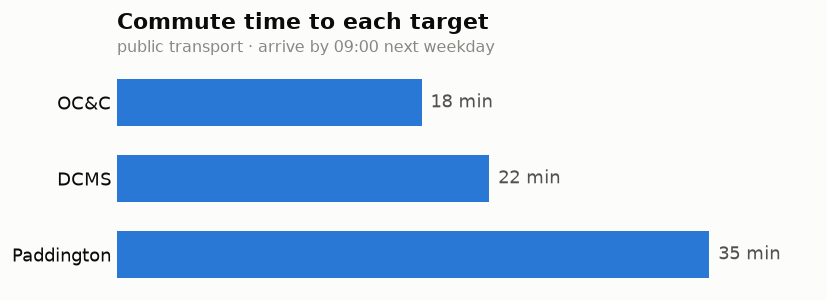

In [4]:
import matplotlib.pyplot as plt

# Data-viz roles (light surface): one series -> one hue, text in ink tokens.
SURFACE, INK, INK2, MUTED, SERIES = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#2a78d6"

# Sort longest-first so barh draws the shortest commute at the top.
items = [(n, r["minutes"]) for n, r in result.items() if r["minutes"] is not None]
items.sort(key=lambda kv: kv[1], reverse=True)
names = [n for n, _ in items]
mins = [m for _, m in items]

fig, ax = plt.subplots(figsize=(7, 2.6), dpi=120)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

bars = ax.barh(names, mins, height=0.62, color=SERIES, zorder=3)
for b, m in zip(bars, mins):  # direct value labels — no x-axis needed
    ax.text(b.get_width() + max(mins) * 0.015, b.get_y() + b.get_height() / 2,
            f"{m} min", va="center", ha="left", color=INK2, fontsize=11)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_xlim(0, max(mins) * 1.18)
ax.tick_params(axis="both", length=0, labelcolor=INK, labelsize=11)
ax.set_title("Commute time to each target", color=INK, fontsize=13,
             fontweight="bold", loc="left", pad=24)
ax.text(0, 1.06, "public transport · arrive by 09:00 next weekday",
        transform=ax.transAxes, color=MUTED, fontsize=9.5, va="bottom")
fig.tight_layout()
plt.show()